In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "dell",
                             database = "ecommerce")


cur = db.cursor()


# list all unique cities where customers are located

In [10]:
query = """ select distinct customer_city from customers """

cur.execute(query)

data = cur.fetchall()

data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# count the number of order placed in 2017


In [8]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()

data

[(90202,)]

# find total sales per category

In [14]:
query = """ select products.product_category category,
round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""
cur.execute(query)

data = cur.fetchall()

data

[('perfumery', 4053909.28),
 ('Furniture Decoration', 11441411.13),
 ('telephony', 3895056.41),
 ('bed table bath', 13700429.37),
 ('automotive', 6818354.65),
 ('computer accessories', 12682643.57),
 ('housewares', 8758065.04),
 ('babies', 4318765.28),
 ('toys', 4952301.52),
 ('Furniture office', 5174611.9),
 ('Cool Stuff', 6237584.0),
 ('HEALTH BEAUTY', 13258984.96),
 ('pet Shop', 2490151.76),
 ('General Interest Books', 517558.08),
 ('stationary store', 2539520.56),
 ('Watches present', 11433733.43),
 ('PCs', 2232972.39),
 ('climatization', 729365.28),
 ('Construction Tools Construction', 1931805.04),
 ('sport leisure', 11137020.47),
 ('Bags Accessories', 1497210.32),
 ('electronics', 2078856.8),
 ('Casa Construcao', 1093162.32),
 ('Games consoles', 1563843.03),
 ('Fashion Bags and Accessories', 1745266.24),
 ('home appliances', 764258.16),
 ('Garden tools', 6706246.01),
 ('Agro Industria e Comercio', 949844.88),
 (None, 2022413.68),
 ('audio', 482596.96),
 ('technical books', 199323

# count number of customer from each state

In [17]:
query = """ select customer_state ,count(customer_id) from customers
group by customer_state """

cur.execute(query)

data = cur.fetchall()

data

[('SP', 83492),
 ('SC', 7274),
 ('MG', 23270),
 ('PR', 10090),
 ('RJ', 25704),
 ('RS', 10932),
 ('PA', 1950),
 ('GO', 4040),
 ('ES', 4066),
 ('BA', 6760),
 ('MA', 1494),
 ('MS', 1430),
 ('CE', 2672),
 ('DF', 4280),
 ('RN', 970),
 ('PE', 3304),
 ('MT', 1814),
 ('AM', 296),
 ('AP', 136),
 ('AL', 826),
 ('RO', 506),
 ('PB', 1072),
 ('TO', 560),
 ('PI', 990),
 ('AC', 162),
 ('SE', 700),
 ('RR', 92)]

# calculate the percentage of order that were paid in installments.

In [16]:
query = """ select (sum(case when payment_installments >= 1 then 1
else 0 end))/count(*)*100 from payments"""

cur.execute(query)

data = cur.fetchall()

data
"the percentage of order that were paid in installments is", data[0][0]

('the percentage of order that were paid in installments is',
 Decimal('99.9981'))

# count the number of customers id from each state

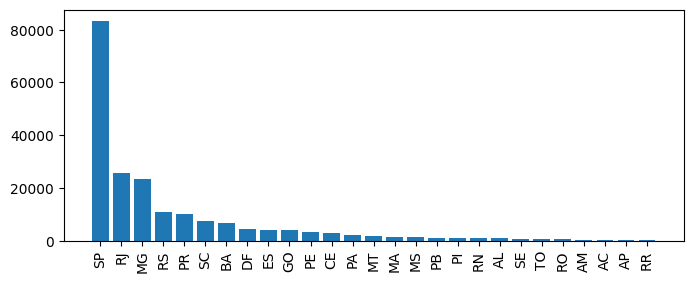

In [17]:
query = """ select customer_state , count(customer_id)
from customers group by customer_state"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = [ "state", "customer_count" ])
df = df.sort_values(by = "customer_count", ascending= False)

plt.figure(figsize = (8,3))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation = 90)
plt.show()

                                   

# calculate the number of order per month in 2018

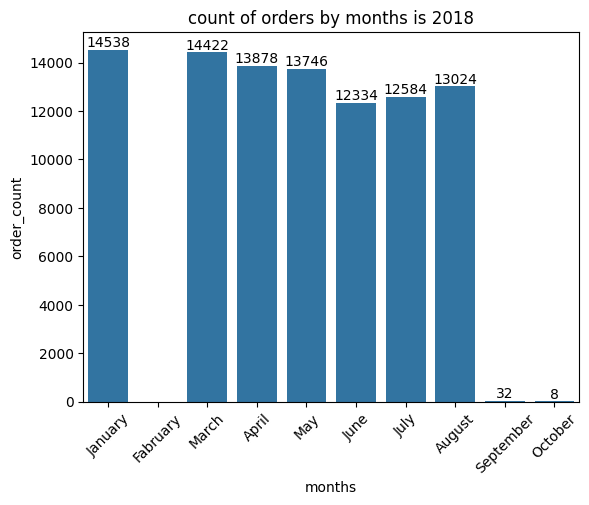

In [15]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
 """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "Fabruary", "March", "April", "May", "June", "July", "August","September","October"]

ax = sns.barplot(x = df["months"],y =  df["order_count"], data = df, order = o)
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("count of orders by months is 2018")
plt.show()

# find the average number of product per order , group by customers city.

In [2]:
query = """with count_per_order as
(select orders.order_id,orders.customer_id, count(order_items.order_id)as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city; """

cur.execute(query)

data = cur.fetchall()

data

[('sao paulo', Decimal('4.62')),
 ('sao jose dos campos', Decimal('4.55')),
 ('porto alegre', Decimal('4.70')),
 ('indaial', Decimal('4.46')),
 ('treze tilias', Decimal('5.09')),
 ('rio de janeiro', Decimal('4.59')),
 ('mario campos', Decimal('5.33')),
 ('guariba', Decimal('4.00')),
 ('cuiaba', Decimal('4.79')),
 ('franca', Decimal('5.01')),
 ('tocos', Decimal('4.00')),
 ('januaria', Decimal('4.73')),
 ('campinas', Decimal('4.63')),
 ('embu-guacu', Decimal('4.96')),
 ('cerquilho', Decimal('4.67')),
 ('belo horizonte', Decimal('4.57')),
 ('taubate', Decimal('4.54')),
 ('arcos', Decimal('4.48')),
 ('monte mor', Decimal('4.31')),
 ('vianopolis', Decimal('5.33')),
 ('cacapava', Decimal('4.65')),
 ('sao jose da tapera', Decimal('4.00')),
 ('belford roxo', Decimal('4.36')),
 ('pedro leopoldo', Decimal('5.00')),
 ('arroio do sal', Decimal('5.14')),
 ('sao bernardo do campo', Decimal('4.57')),
 ('brasilia', Decimal('4.52')),
 ('ribeirao pires', Decimal('4.49')),
 ('contagem', Decimal('4.58')),

# calculate the percantage of total revenue contributed by each category.

In [9]:
query = """ select upper(products.product_category) category,
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc; """

cur.execute(query)

data = cur.fetchall()

data

[('BED TABLE BATH', 42.79),
 ('HEALTH BEAUTY', 41.41),
 ('COMPUTER ACCESSORIES', 39.61),
 ('FURNITURE DECORATION', 35.73),
 ('WATCHES PRESENT', 35.71),
 ('SPORT LEISURE', 34.78),
 ('HOUSEWARES', 27.35),
 ('AUTOMOTIVE', 21.3),
 ('GARDEN TOOLS', 20.95),
 ('COOL STUFF', 19.48),
 ('FURNITURE OFFICE', 16.16),
 ('TOYS', 15.47),
 ('BABIES', 13.49),
 ('PERFUMERY', 12.66),
 ('TELEPHONY', 12.17),
 ('STATIONARY STORE', 7.93),
 ('PET SHOP', 7.78),
 ('PCS', 6.97),
 ('ELECTRONICS', 6.49),
 (None, 6.32),
 ('CONSTRUCTION TOOLS CONSTRUCTION', 6.03),
 ('MUSICAL INSTRUMENTS', 5.82),
 ('ELECTROSTILE', 5.64),
 ('FASHION BAGS AND ACCESSORIES', 5.45),
 ('FIXED TELEPHONY', 5.17),
 ('GAMES CONSOLES', 4.88),
 ('BAGS ACCESSORIES', 4.68),
 ('CASA CONSTRUCAO', 3.41),
 ('ROOM FURNITURE', 3.4),
 ('ELECTRICES 2', 3.11),
 ('AGRO INDUSTRIA E COMERCIO', 2.97),
 ('HOME APPLIANCES', 2.39),
 ('CLIMATIZATION', 2.28),
 ('HOUSE COMFORT', 2.11),
 ('FURNITURE KITCHEN SERVICE AREA DINNER AND GARDEN', 1.87),
 ('CONSTRUCTION TOOLS

# identify the correlation between product price and the number of times a product has been purchase

In [2]:
query = """select products. product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category """

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Category", "order_count", "price"])

arr1 = df["order_count"]
arr2 = df["price"]
a = np.corrcoef([arr1,arr2])
print("the correlation between product price and the number of times a product has been purchase" , a[0][1])


the correlation between product price and the number of times a product has been purchase -0.10631514167157562



 # Calculate the moving average of order values for each customer over their order history.


In [2]:
query = """select customer_id, order_purchase_timestamp,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from

(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id) as a;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df


,0,1,2
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
4,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
...,...,...,...
415539,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000
415540,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.370001
415541,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.370001
415542,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.370001


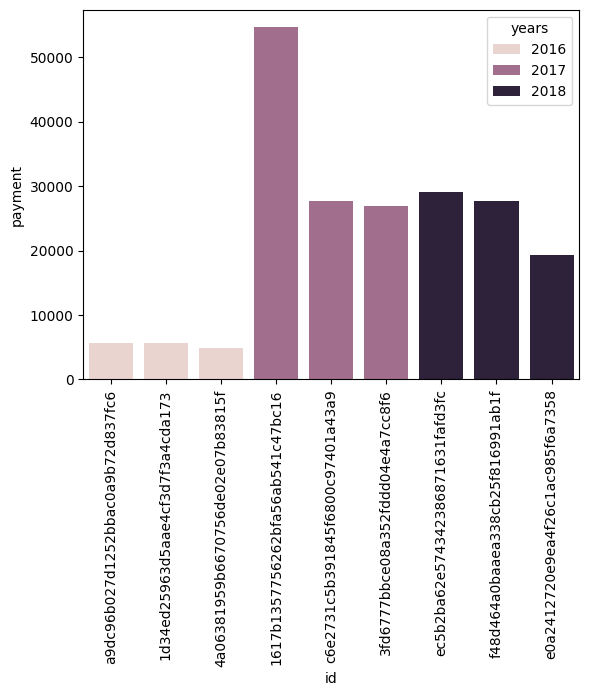

In [3]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3 ;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years","id","payment","rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()

'C:\\Users\\sanjay kumar arya'